In [63]:
!pip install wordcloud nltk
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.classify import NaiveBayesClassifier
from nltk.classify.util import accuracy
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/valentinamorillo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/valentinamorillo/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [64]:
#load data
df = pd.read_csv("amazon_cells_labelled.csv", header=None)
print("Original data:")
print(df.head())
print("\nShape:")
print(df.shape)

Original data:
                                                   0                  1    2  \
0  So there is no way for me to plug it in here i...                  0  NaN   
1                                          Good case   Excellent value.    1   
2                             Great for the jawbone.                  1  NaN   
3  Tied to charger for conversations lasting more...                  0  NaN   
4                                  The mic is great.                  1  NaN   

     3    4   5  
0  NaN  NaN NaN  
1  NaN  NaN NaN  
2  NaN  NaN NaN  
3  NaN  NaN NaN  
4  NaN  NaN NaN  

Shape:
(1000, 6)


In [65]:
#data preprocessing
df["label"] = df.apply(
    lambda row: row.dropna().iloc[-1],
    axis=1
)

df["text"] = df.apply(
    lambda row: " ".join(
        row.dropna().astype(str).iloc[:-1]
    ),
    axis=1
)

#get rid of 0 and 1 at end
df["text"] = df["text"].str.replace(
    r"\s+[01]$",
    "",
    regex=True
)

df = df[["text", "label"]]
df["label"] = df["label"].astype(int)

print("Cleaned data:")
print(df.head())
print("\nDataset information:")
print(df.info())

Cleaned data:
                                                text  label
0  So there is no way for me to plug it in here i...      0
1                        Good case  Excellent value.      1
2                             Great for the jawbone.      1
3  Tied to charger for conversations lasting more...      0
4                                  The mic is great.      1

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1000 non-null   object
 1   label   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB
None


/var/folders/vh/d7rz6cr55nz09sm9yf2f6qnw0000gn/T/ipykernel_2532/316724989.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = df["label"].astype(int)


In [66]:
def extract_features(words): 
    return dict(
        [(word, True) for word in words]
    )

In [68]:
#positive and negative review list
positive_reviews = []
negative_reviews = []
for index, row in df.iterrows():
    words = word_tokenize(row["text"])
    features = extract_features(words)
    if row["label"] == 1:
        positive_reviews.append((features, "Positive"))
    else:
        negative_reviews.append((features, "Negative"))

In [49]:
#percentages
sentiment_percent = (
    df["sentiment"]
    .value_counts(normalize=True)
    * 100
)
print("Sentiment Percentages:")
print(sentiment_percent)

Sentiment Percentages:
sentiment
Positive    48.3
Negative    27.9
Neutral     23.8
Name: proportion, dtype: float64


In [69]:
#split training and testing
threshold_factor = 0.8
threshold_positive = int(
    threshold_factor * len(positive_reviews)
)
threshold_negative = int(
    threshold_factor * len(negative_reviews)
)
features_train = (
    positive_reviews[:threshold_positive]
    + negative_reviews[:threshold_negative]
)
features_test = (
    positive_reviews[threshold_positive:]
    + negative_reviews[threshold_negative:]
)
print("Number of training datapoints:",
      len(features_train))
print("Number of test datapoints:",
      len(features_test))

Number of training datapoints: 800
Number of test datapoints: 200


In [70]:
#naive bayes classifier
classifier = NaiveBayesClassifier.train(
    features_train
)
print("Accuracy of the classifier:",
      accuracy(classifier, features_test))

Accuracy of the classifier: 0.76


In [71]:
#important words
print("Top 10 most informative words:")
for item in classifier.most_informative_features()[:10]:
    print(item)

Top 10 most informative words:
('works', True)
('price', True)
('great', True)
('best', True)
('If', True)
('Not', True)
('Excellent', True)
('fine', True)
('not', True)
('Does', True)


In [72]:
#predictions
input_reviews = [
    "This phone is amazing",
    "I hate this product",
    "Battery life is great",
    "The product is terrible"
]
print("Predictions:")
for review in input_reviews:
    words = word_tokenize(review)
    features = extract_features(words)
    predicted_sentiment = classifier.classify(features)
    print("\nReview:", review)
    print("Predicted sentiment:",
          predicted_sentiment)

Predictions:

Review: This phone is amazing
Predicted sentiment: Positive

Review: I hate this product
Predicted sentiment: Negative

Review: Battery life is great
Predicted sentiment: Positive

Review: The product is terrible
Predicted sentiment: Negative


In [73]:
#perform sentiment analysis
def get_sentiment(text):
    words = word_tokenize(text)
    features = extract_features(words)
    return classifier.classify(features)
df["sentiment"] = df["text"].apply(
    get_sentiment
)
print(df[["text", "sentiment"]].head())

                                                text sentiment
0  So there is no way for me to plug it in here i...  Negative
1                        Good case  Excellent value.  Positive
2                             Great for the jawbone.  Positive
3  Tied to charger for conversations lasting more...  Negative
4                                  The mic is great.  Positive


/var/folders/vh/d7rz6cr55nz09sm9yf2f6qnw0000gn/T/ipykernel_2532/2720470087.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sentiment"] = df["text"].apply(


In [74]:
# percentages
sentiment_percent = (
    df["sentiment"]
    .value_counts(normalize=True)
    * 100
)
print("Sentiment Percentages:")
print(sentiment_percent)

Sentiment Percentages:
sentiment
Negative    51.1
Positive    48.9
Name: proportion, dtype: float64


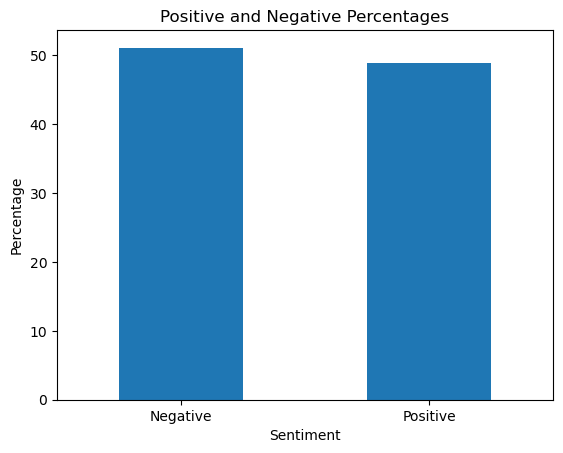

In [75]:
#bar graph
sentiment_percent.plot(kind="bar")
plt.title("Positive and Negative Percentages")
plt.xlabel("Sentiment")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

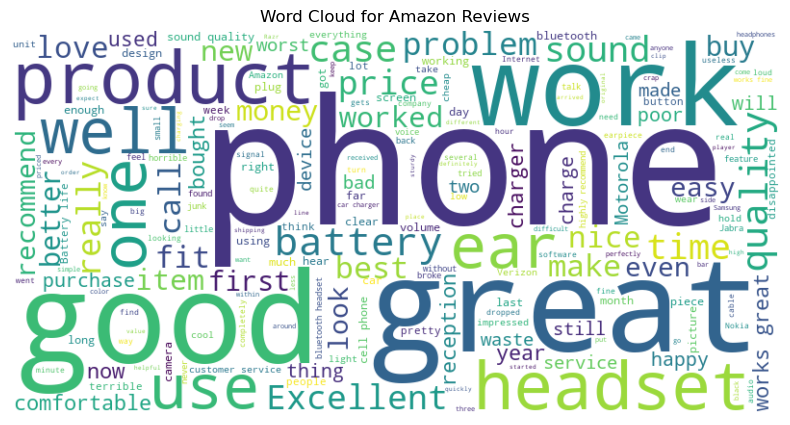

In [76]:
#word cloud
all_text = " ".join(df["text"])
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud,
           interpolation="bilinear")

plt.axis("off")
plt.title("Word Cloud for Amazon Reviews")
plt.show()

In [77]:
#emotion percentages
emotion_counts = (
    df["sentiment"]
    .value_counts()
)
emotion_df = pd.DataFrame({
    "Emotion": emotion_counts.index,
    "Count": emotion_counts.values
})
emotion_df["Percentage"] = (
    emotion_df["Count"]
    / emotion_df["Count"].sum()
) * 100
print(emotion_df)

    Emotion  Count  Percentage
0  Negative    511        51.1
1  Positive    489        48.9


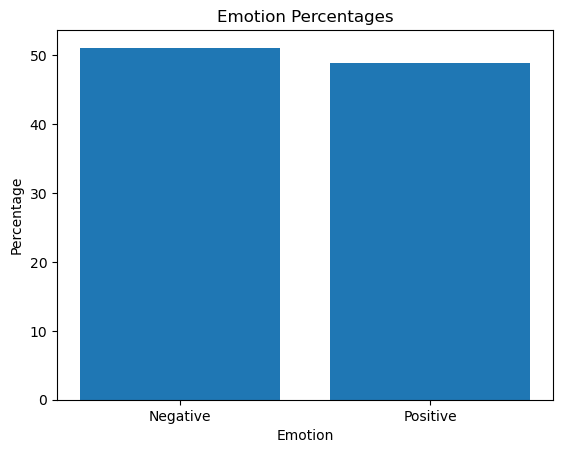

In [78]:
#emotion bar graph 
plt.bar(
    emotion_df["Emotion"],
    emotion_df["Percentage"]
)
plt.title("Emotion Percentages")
plt.xlabel("Emotion")
plt.ylabel("Percentage")
plt.show()

In [ ]:
#In this hw assigment i used the dataset that contained amazon product reviews and sentiment labels
#After i loaded the data i cleaned and processed it
#I used NLTK Naive bayes sentiment analysis to classify reveiws
#reviews were classifies into positive or nrgative
#i then created word clousds and bar graohs to vizualize the data
#from this hw i leanred how NLP can be used to analysze customer optionions from textual data